In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [3]:
# Make the corner plot for the MCMC results
system_name = 'GRAL1131'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [4]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,24.05553,246.6850,-0.080114,0.775713,0.175779,-4.695918
1,24.09396,246.6890,-0.081642,0.775648,0.175753,-4.703768
2,25.37725,246.7565,-0.083563,0.775149,0.178477,-4.696616
3,24.25757,246.8350,-0.079032,0.774820,0.179250,-4.692042
4,24.13125,246.7867,-0.079201,0.775290,0.179490,-4.694899
...,...,...,...,...,...,...
2833,25.11015,246.7545,-0.073625,0.766082,0.205806,-4.634998
2834,27.18209,246.7483,-0.070241,0.765428,0.203596,-4.637213
2835,25.53442,246.7519,-0.076762,0.765764,0.203706,-4.651319
2836,25.18542,246.8831,-0.076357,0.765061,0.202795,-4.646838


In [5]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [16]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

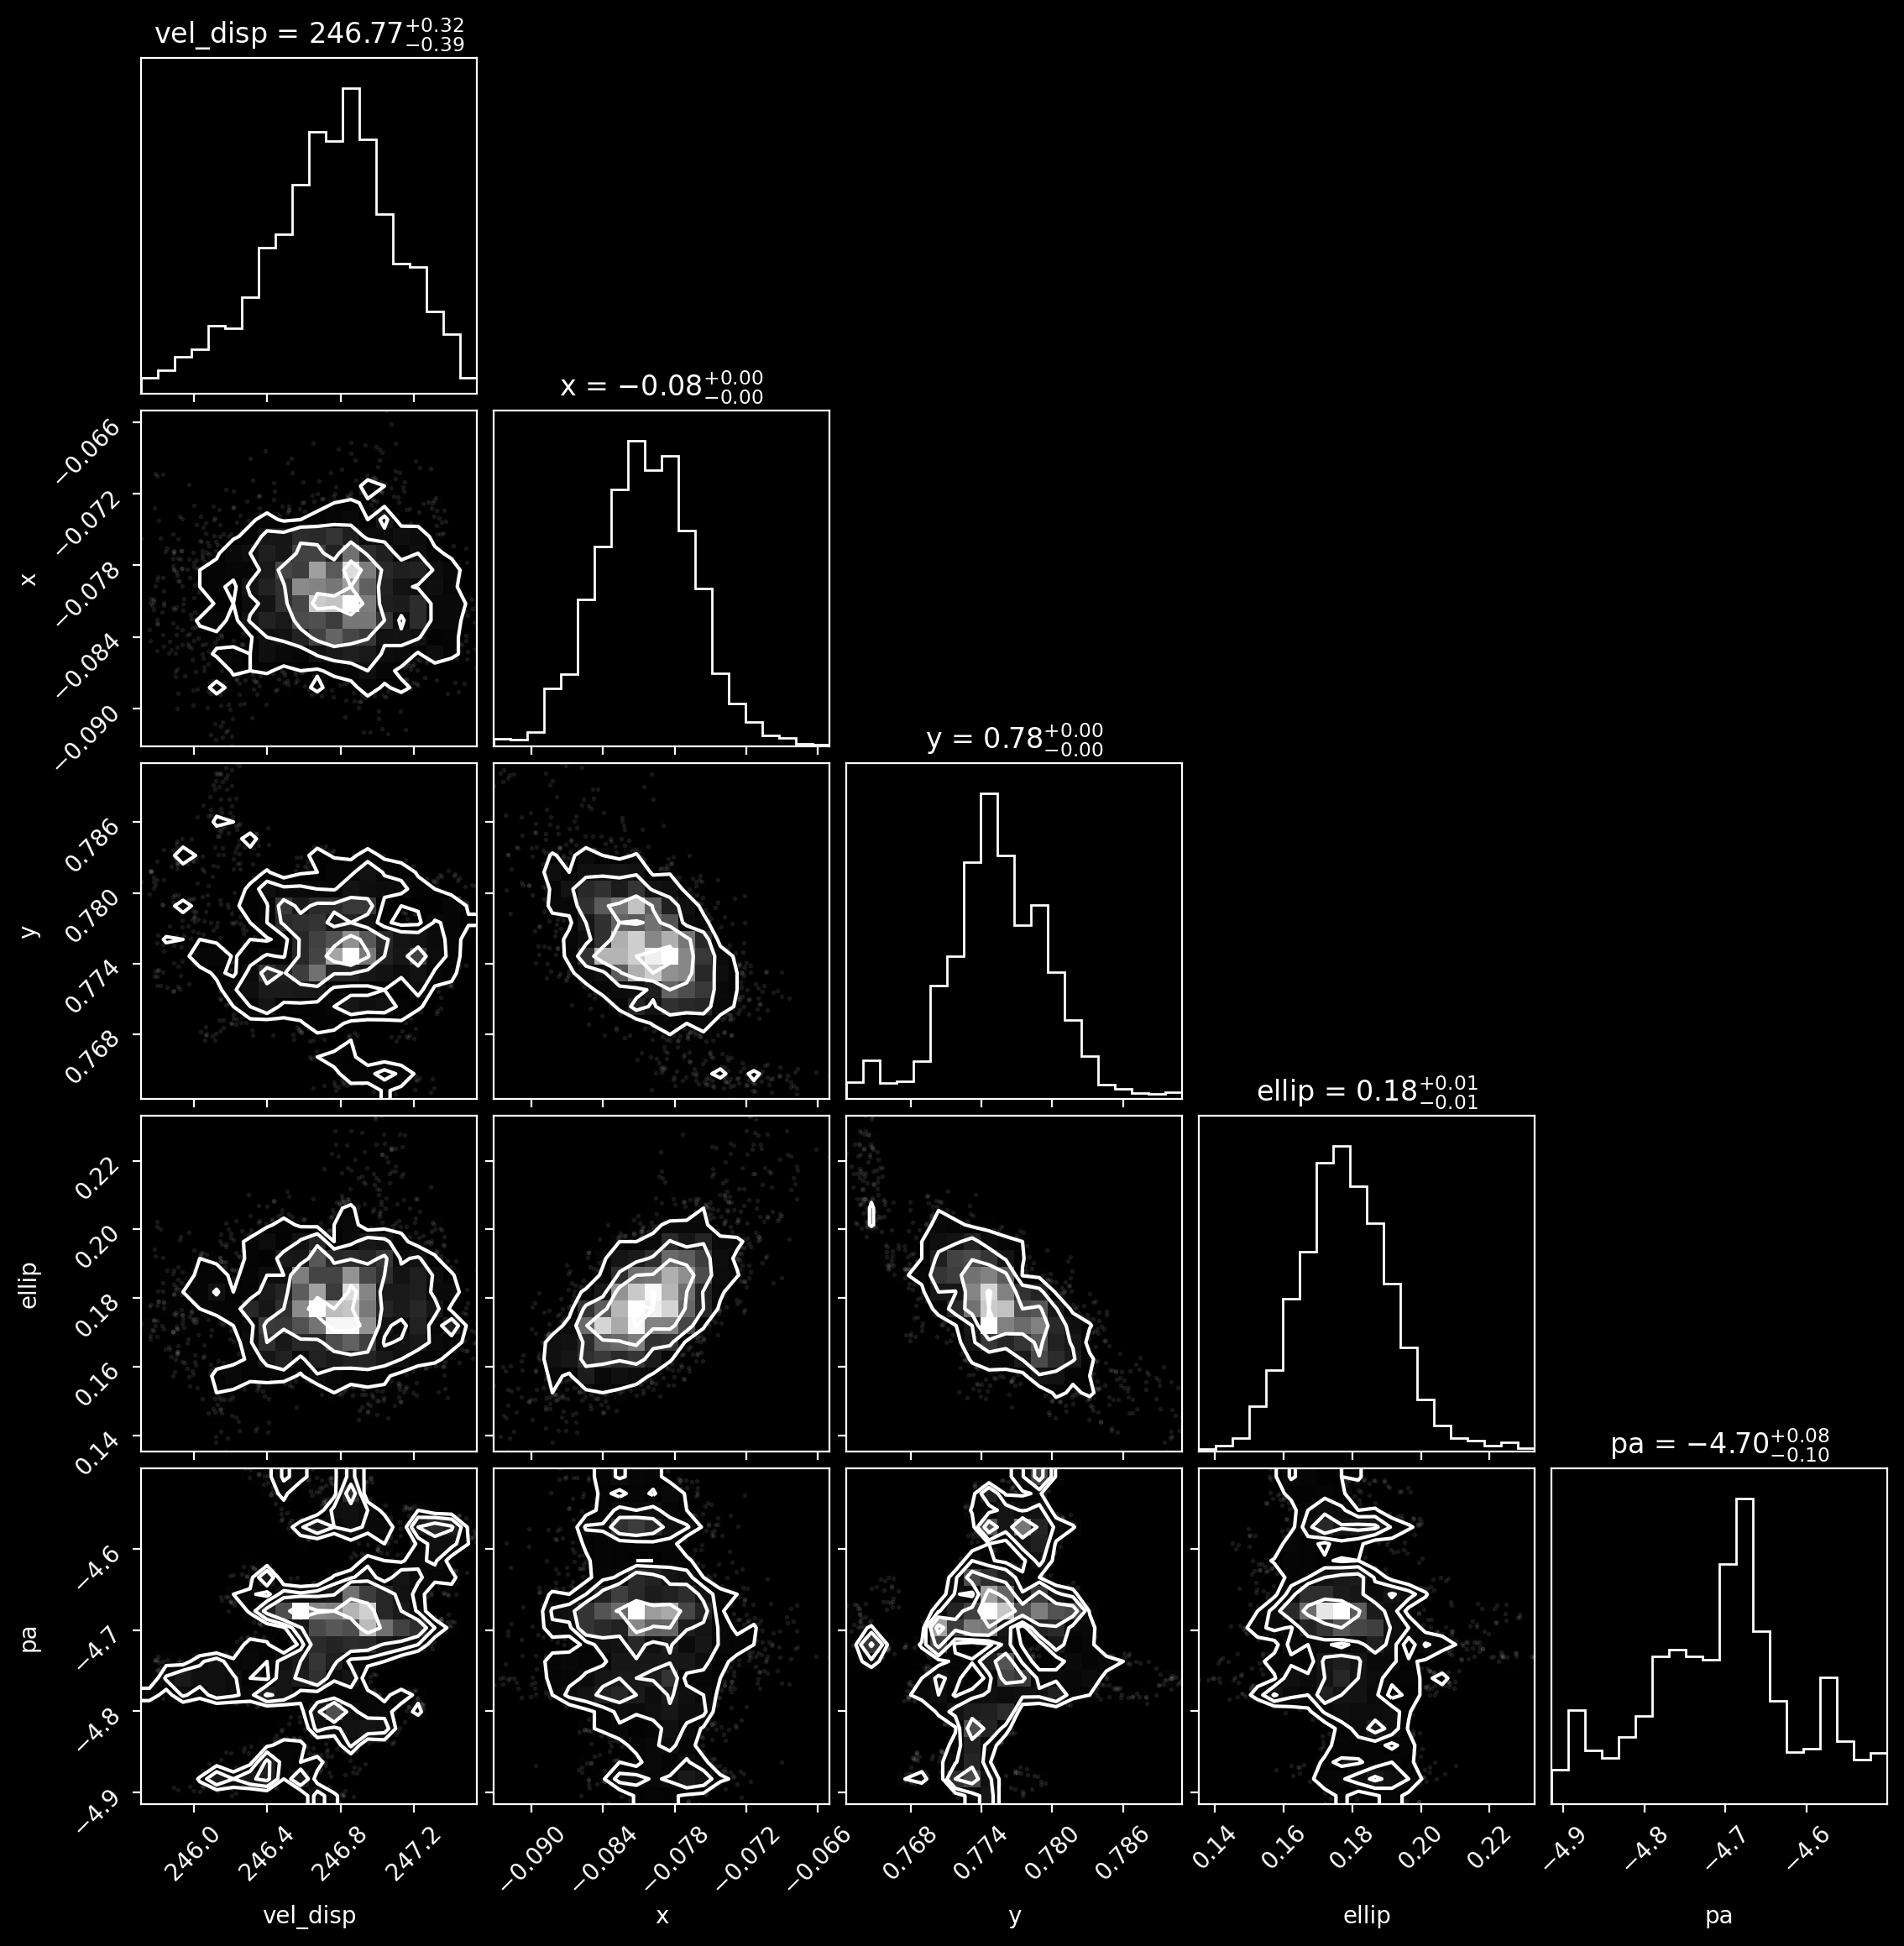

In [6]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')